# DCGAN on MNIST - Assignment 3

**Name:** Laiba Bint-e-Zia  
**Roll No:** 23k-0006  

The goal of this assignment is to implement a Deep Convolutional GAN (DCGAN) to generate handwritten digits using the MNIST dataset.

A GAN has two networks:
- **Generator**: takes random noise and tries to make fake images that look real
- **Discriminator**: tries to tell apart real images from fake ones

They basically compete against each other, and over time the generator gets better at fooling the discriminator.

## Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using device:', device)

using device: cuda


## Hyperparameters

I mostly used the values from the paper. Batch size 128 worked fine, I tried 64 first but training was slower. NZ=100 is the latent vector size (also from the paper).

In [2]:
IMAGE_SIZE  = 64
NC          = 1       # grayscale so 1 channel
NZ          = 100     # latent vector size
NGF         = 64      # generator feature maps
NDF         = 64      # discriminator feature maps
NUM_EPOCHS  = 25
BATCH_SIZE  = 128
LR          = 0.0002  # from the paper
BETA1       = 0.5     # paper says use 0.5 instead of default 0.9

os.makedirs('./data', exist_ok=True)
os.makedirs('./outputs', exist_ok=True)

## Dataset

Using MNIST from torchvision. I resized to 64x64 because the DCGAN architecture works with powers of 2. Normalized to [-1, 1] to match the tanh activation at the end of the generator.

In [3]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalize to [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

print('dataset size:', len(dataset))
print('batches per epoch:', len(dataloader))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 18.2MB/s]

dataset size: 60000
batches per epoch: 469


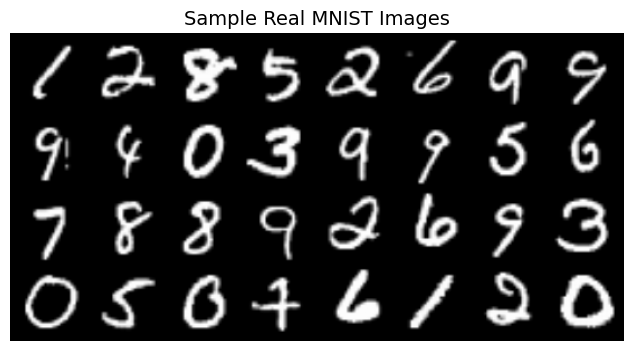

In [4]:
# just checking what the data looks like
real_batch = next(iter(dataloader))

plt.figure(figsize=(10, 4))
plt.axis('off')
plt.title('Sample Real MNIST Images', fontsize=14)
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[0][:32], nrow=8, padding=2, normalize=True).cpu(),
        (1, 2, 0)
    ), cmap='gray'
)
plt.show()

## Weight Initialization

The paper says to initialize weights from Normal(0, 0.02). BatchNorm weights are initialized to 1 and biases to 0.

In [5]:
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## Generator

The generator takes a noise vector z of size 100 and upsamples it to a 64x64 image using transposed convolutions (sometimes called deconvolutions). Each layer doubles the spatial size.

Architecture:
```
z: (100, 1, 1)
-> ConvTranspose2d -> (512, 4, 4)    + BN + ReLU
-? ConvTranspose2d -> (256, 8, 8)    + BN + ReLU
-> ConvTranspose2d -> (128, 16, 16)  + BN + ReLU
-> ConvTranspose2d -> (64,  32, 32)  + BN + ReLU
-> ConvTranspose2d -> (1,   64, 64)  + Tanh
```

No BN on the output layer. Tanh squishes output to [-1, 1].

In [6]:
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # z goes in as (nz, 1, 1)
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),
            # (ngf*8, 4, 4)
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            # (ngf*4, 8, 8)
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            # (ngf*2, 16, 16)
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # (ngf, 32, 32)
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # output: (nc, 64, 64)
        )

    def forward(self, x):
        return self.main(x)


netG = Generator(NZ, NGF, NC).to(device)
netG.apply(weights_init)
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


## Discriminator

The discriminator is basically the reverse, it takes a 64x64 image and outputs a single value (probability of being real). Uses strided convolutions instead of pooling (as recommended in the paper). LeakyReLU with slope 0.2 is used instead of regular ReLU.

Note: no BN on the first layer (paper says so).

In [7]:
class Discriminator(nn.Module):
    def __init__(self, nc, ndf):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input: (nc, 64, 64) : no batchnorm on first layer
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf, 32, 32)
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2, 16, 16)
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4, 8, 8)
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8, 4, 4)
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)


netD = Discriminator(NC, NDF).to(device)
netD.apply(weights_init)
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


## Loss and Optimizers

Using Binary Cross Entropy loss. For the labels I used 0.9 for real instead of 1.0, this is called label smoothing and makes training a bit more stable (the discriminator doesn't become too confident).

In [8]:
criterion = nn.BCELoss()

REAL_LABEL = 0.9  # label smoothing
FAKE_LABEL = 0.0

# fixed noise so we can track generator progress across epochs
fixed_noise = torch.randn(64, NZ, 1, 1, device=device)

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

## Training

Each iteration we do two updates:

**Step 1: Update Discriminator:**
- Run real images through D, compute loss vs real labels
- Generate fake images with G, run through D, compute loss vs fake labels  
- Add both losses, backprop, update D

**Step 2: Update Generator:**
- Generate fake images, run through D
- But this time compute loss vs *real* labels (we want G to fool D)
- Backprop through D into G, update G only

In [9]:
G_losses = []
D_losses = []
img_list = []

print('starting training...')
start = time.time()

for epoch in range(NUM_EPOCHS):
    for i, (real_imgs, _) in enumerate(dataloader):

        b_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # (1) Update Discriminator
        netD.zero_grad()

        # real batch
        label = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=device)
        output = netD(real_imgs)
        lossD_real = criterion(output, label)
        lossD_real.backward()
        D_x = output.mean().item()

        # fake batch
        noise = torch.randn(b_size, NZ, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(FAKE_LABEL)
        output = netD(fake.detach())  # detach so we dont update G here
        lossD_fake = criterion(output, label)
        lossD_fake.backward()
        D_G_z1 = output.mean().item()

        lossD = lossD_real + lossD_fake
        optimizerD.step()

        # (2) Update Generator
        netG.zero_grad()

        label.fill_(REAL_LABEL)  # generator wants D to think fake is real
        output = netD(fake)
        lossG = criterion(output, label)
        lossG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

        if i % 100 == 0:
            print(f'[{epoch+1}/{NUM_EPOCHS}][{i}/{len(dataloader)}]  '
                  f'Loss_D: {lossD.item():.4f}  Loss_G: {lossG.item():.4f}  '
                  f'D(x): {D_x:.4f}  D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}')

    # save output after each epoch
    with torch.no_grad():
        fake_fixed = netG(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake_fixed, nrow=8, padding=2, normalize=True))
    vutils.save_image(fake_fixed[:16], f'./outputs/epoch_{epoch+1:03d}.png', nrow=4, normalize=True)

print(f'done! took {(time.time()-start)/60:.1f} minutes')

starting training...
[1/25][0/469]  Loss_D: 1.6781  Loss_G: 6.3979  D(x): 0.7703  D(G(z)): 0.6386/0.0015
[1/25][100/469]  Loss_D: 0.6097  Loss_G: 5.3965  D(x): 0.8943  D(G(z)): 0.1459/0.0037
[1/25][200/469]  Loss_D: 0.4589  Loss_G: 3.7460  D(x): 0.8915  D(G(z)): 0.0791/0.0208
[1/25][300/469]  Loss_D: 0.5074  Loss_G: 2.6724  D(x): 0.7827  D(G(z)): 0.0894/0.0651
[1/25][400/469]  Loss_D: 0.5772  Loss_G: 3.4682  D(x): 0.8631  D(G(z)): 0.1852/0.0293
[2/25][0/469]  Loss_D: 0.4232  Loss_G: 2.7967  D(x): 0.8304  D(G(z)): 0.0525/0.0527
[2/25][100/469]  Loss_D: 0.4977  Loss_G: 2.3364  D(x): 0.7908  D(G(z)): 0.0967/0.0908
[2/25][200/469]  Loss_D: 0.6685  Loss_G: 2.1138  D(x): 0.7474  D(G(z)): 0.2069/0.1090
[2/25][300/469]  Loss_D: 0.5122  Loss_G: 2.5557  D(x): 0.7777  D(G(z)): 0.0983/0.0740
[2/25][400/469]  Loss_D: 0.7025  Loss_G: 1.5506  D(x): 0.6221  D(G(z)): 0.1200/0.2147
[3/25][0/469]  Loss_D: 0.6779  Loss_G: 2.5504  D(x): 0.8150  D(G(z)): 0.2381/0.0773
[3/25][100/469]  Loss_D: 0.6127  Loss_G

## Results

### Training Loss Curves

Ideally G and D losses should both hover around a moderate value. If D loss goes to 0 it means the discriminator is winning too easily. If G loss explodes it means the generator is failing.

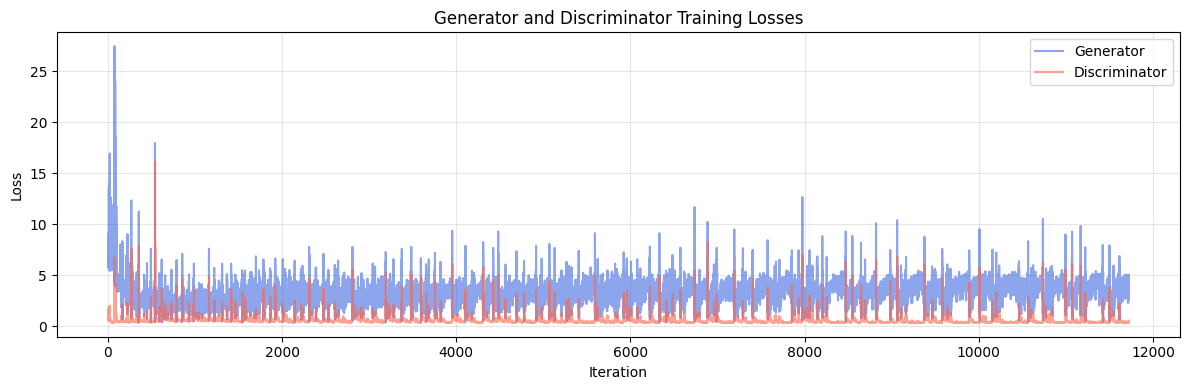

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(G_losses, label='Generator', alpha=0.6, color='royalblue')
plt.plot(D_losses, label='Discriminator', alpha=0.6, color='tomato')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Generator and Discriminator Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/loss_curves.png', dpi=150)
plt.show()

### Generated Samples (64 images)

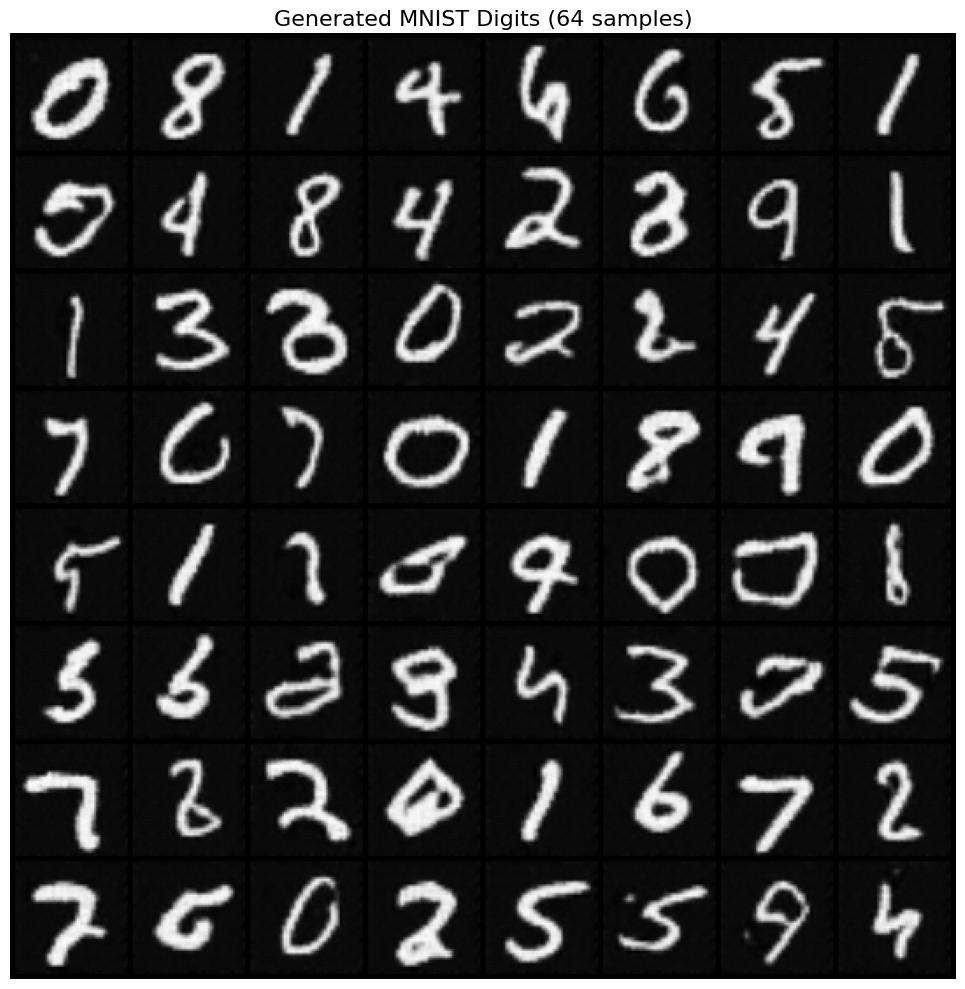

In [11]:
netG.eval()
with torch.no_grad():
    generated = netG(fixed_noise).detach().cpu()

plt.figure(figsize=(10, 10))
plt.axis('off')
plt.title('Generated MNIST Digits (64 samples)', fontsize=16)
grid = vutils.make_grid(generated, nrow=8, padding=3, normalize=True)
plt.imshow(np.transpose(grid, (1, 2, 0)), cmap='gray')
plt.tight_layout()
plt.savefig('./outputs/generated_64_samples.png', dpi=150, bbox_inches='tight')
plt.show()

### 10 Generated Digits (Assignment Requirement)

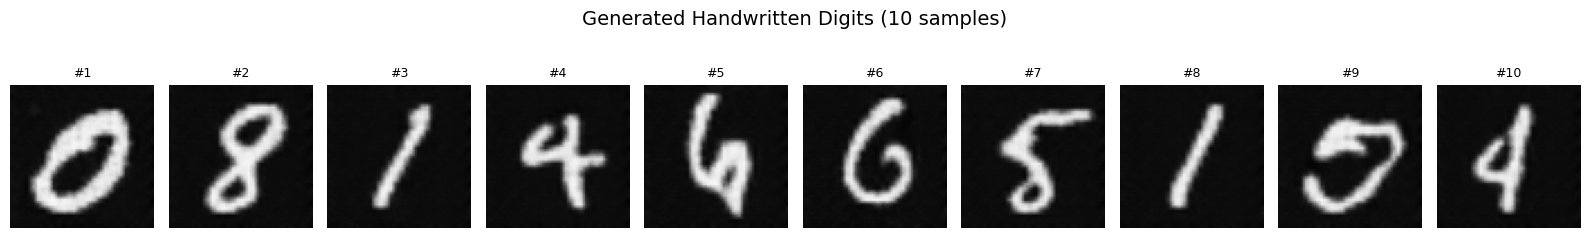

In [12]:
fig, axes = plt.subplots(1, 10, figsize=(16, 2.5))
fig.suptitle('Generated Handwritten Digits (10 samples)', fontsize=14, y=1.02)

for idx in range(10):
    img = generated[idx].squeeze().numpy()
    img = (img * 0.5 + 0.5)  # denormalize back to [0,1]
    axes[idx].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[idx].set_title(f'#{idx+1}', fontsize=9)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('./outputs/generated_10_digits.png', dpi=150, bbox_inches='tight')
plt.show()

### Real vs Fake Comparison

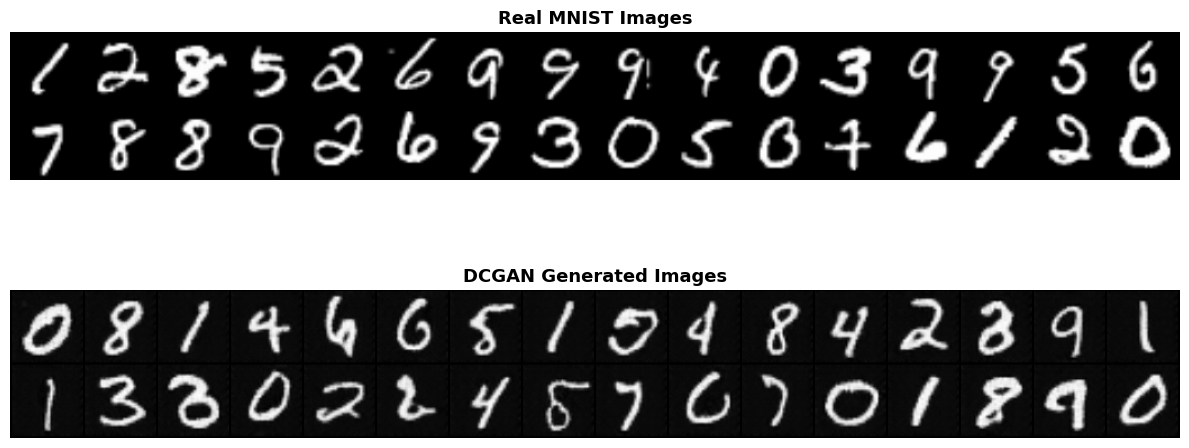

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

real_grid = vutils.make_grid(real_batch[0][:32].cpu(), nrow=16, padding=2, normalize=True)
axes[0].imshow(np.transpose(real_grid, (1, 2, 0)), cmap='gray')
axes[0].set_title('Real MNIST Images', fontsize=13, fontweight='bold')
axes[0].axis('off')

fake_grid = vutils.make_grid(generated[:32].cpu(), nrow=16, padding=2, normalize=True)
axes[1].imshow(np.transpose(fake_grid, (1, 2, 0)), cmap='gray')
axes[1].set_title('DCGAN Generated Images', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('./outputs/real_vs_fake.png', dpi=150, bbox_inches='tight')
plt.show()

### Latent Space Interpolation

This is a cool thing you can do with GANs, linearly interpolate between two noise vectors and see how the generated image smoothly changes. If the latent space is well structured the transitions should look smooth.

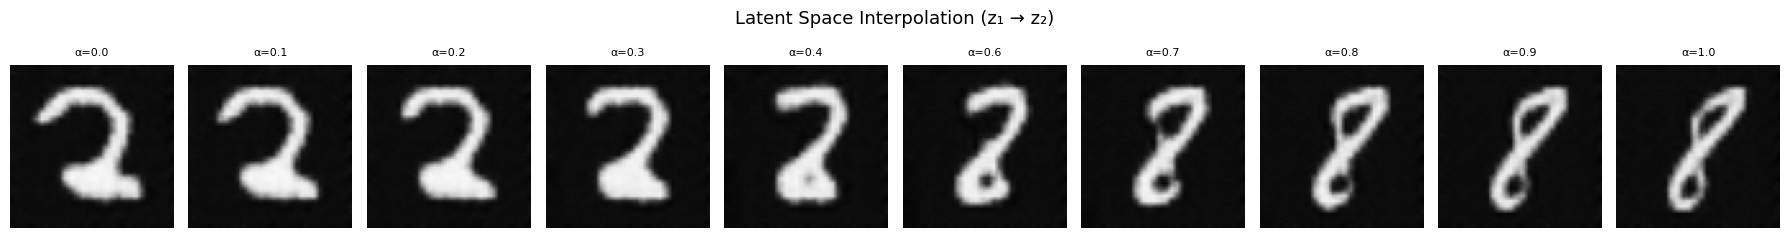

In [14]:
z1 = torch.randn(1, NZ, 1, 1, device=device)
z2 = torch.randn(1, NZ, 1, 1, device=device)

steps = 10
interp_imgs = []

with torch.no_grad():
    for alpha in np.linspace(0, 1, steps):
        z = (1 - alpha) * z1 + alpha * z2
        img = netG(z).squeeze().cpu().numpy()
        interp_imgs.append((img * 0.5 + 0.5).clip(0, 1))

fig, axes = plt.subplots(1, steps, figsize=(18, 2.5))
fig.suptitle('Latent Space Interpolation (z₁ → z₂)', fontsize=13)
for ax, img, alpha in zip(axes, interp_imgs, np.linspace(0, 1, steps)):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'α={alpha:.1f}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('./outputs/interpolation.png', dpi=150, bbox_inches='tight')
plt.show()

### Training Progression

Showing how the generator outputs changed over epochs using the same fixed noise.

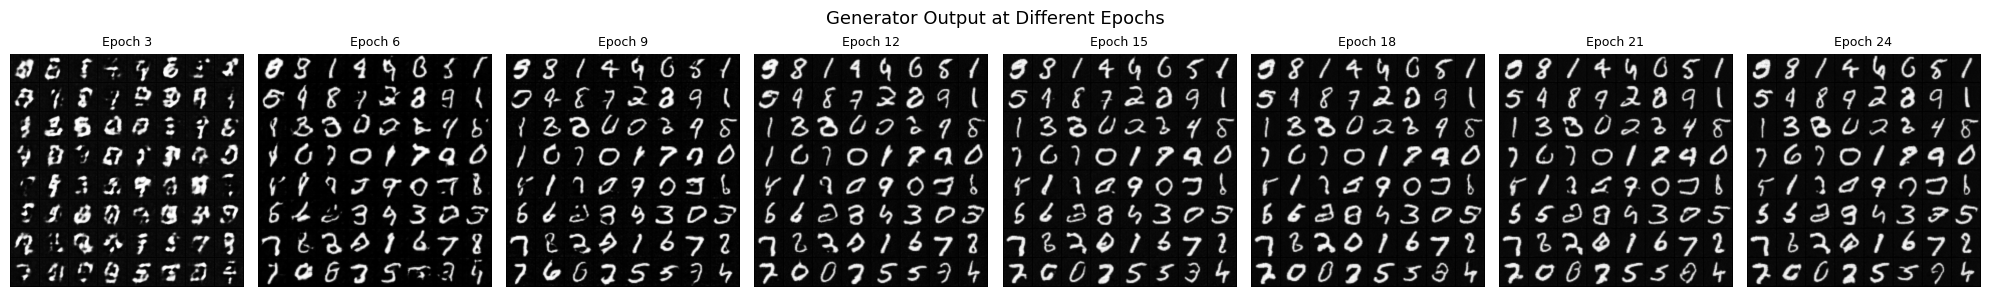

In [15]:
# pick a few epochs to show
n_show = min(8, len(img_list))
step = len(img_list) // n_show
selected = img_list[::step][:n_show]
epoch_nums = list(range(step, NUM_EPOCHS+1, step))[:n_show]

fig, axes = plt.subplots(1, n_show, figsize=(20, 3))
fig.suptitle('Generator Output at Different Epochs', fontsize=13)
for ax, grid, ep in zip(axes, selected, epoch_nums):
    ax.imshow(np.transpose(grid, (1, 2, 0)), cmap='gray')
    ax.set_title(f'Epoch {ep}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('./outputs/progression.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# save the animation as well
fig = plt.figure(figsize=(6, 6))
plt.axis('off')
ims = [[plt.imshow(np.transpose(g, (1, 2, 0)), cmap='gray', animated=True)] for g in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=500, repeat_delay=1000, blit=True)
try:
    ani.save('./outputs/training_animation.gif', writer='pillow', fps=3)
    print('saved animation')
except:
    print('could not save gif, pillow might not be installed')
plt.close()

saved animation


## Save Model

In [17]:
torch.save({
    'generator': netG.state_dict(),
    'discriminator': netD.state_dict(),
    'optimizerG': optimizerG.state_dict(),
    'optimizerD': optimizerD.state_dict(),
    'epoch': NUM_EPOCHS,
}, './outputs/dcgan_mnist.pth')

print('model saved to ./outputs/dcgan_mnist.pth')

model saved to ./outputs/dcgan_mnist.pth


## Discussion

### Architecture Summary

| Component | Details |
|---|---|
| **Generator** | 5 transposed conv layers, ReLU + BatchNorm, Tanh output |
| **Discriminator** | 5 strided conv layers, LeakyReLU(0.2) + BatchNorm, Sigmoid output |
| **Loss** | Binary CrossvEntropy |
| **Optimizer** | Adam, lr=0.0002, β₁=0.5 |
| **Dataset** | MNIST, 60k images, resized to 64×64 |

### Key things I learned from the paper
- Use strided convolutions instead of pooling in the discriminator
- Use transposed convolutions (not upsampling+conv) in the generator  
- BatchNorm helps a lot with stability but don't put it on the first layer of D or last layer of G
- LeakyReLU in D prevents dying gradients, ReLU in G is fine
- β₁=0.5 instead of default 0.9 for Adam - this was mentioned in the paper and apparently helps

### Observations
The generated digits look fairly realistic after 25 epochs. Some are a bit blurry and occasionally you get weird looking ones that don't really look like any digit (mode collapsish behavior). Training was generally stable - the D and G losses both fluctuated but neither completely dominated the other.

Label smoothing (using 0.9 instead of 1.0 for real labels) seemed to help, I tried without it first and the discriminator loss went to near 0 very fast which made training unstable.

### Possible Improvements
- Could try Wasserstein loss (WGAN) which is supposed to be more stable
- Conditional GAN to control which digit gets generated
- Train for more epochs
- Try different architectures (deeper, spectral norm, etc.)